

> **ANALISIS DE PUNTOS DE DOLOR
 LOGISTICA INVERSA**



Hipótesis 1 (Saturación Operativa): Los días con picos de solicitudes de retiro en el AMBA correlacionan fuertemente con una caída del % de SLA y el aumento de "falsos escaneos".

Hipótesis 2 (Agujeros de Sistema): Los retiros "fantasma" (que tienen entrega pero no figuran como "Retirados") no ocurren al azar, Hipótesis: Las inconsistencias de escaneo se concentran en canalizadores y sucursales específicas.
Hipótesis 3 (Riesgo Estructural): El incumplimiento del SLA no depende tanto del volumen, sino del día de la semana en que se solicita el retiro (ej. pedidos de jueves/viernes tienen más demoras por el cruce del fin de semana).


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder

In [64]:


sns.set_theme(style="whitegrid")

nombre_archivo = '/content/consolidado inversas.csv'

try:
    df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')
except:
    # Si falla, probamos con el formato internacional estándar
    df = pd.read_csv(nombre_archivo, encoding='utf-8')

print("Primeras 5 filas del dataset:")
display(df.head())

print("\n--- Información técnica de las columnas ---")
df.info()

Primeras 5 filas del dataset:


/tmp/ipykernel_13726/807011953.py:9: DtypeWarning: Columns (0,13,14,15,17,19,25,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')


,Equipo,Fecha Imposición,AP,Cliente AP,Fecha POD,Fecha HU,CP,Status,Motivo,Fecha 1er Visita,...,Clasif_Inversa_Propia,Clasif_H2H_Propia,ID cliente,Aps H2H ciclo,Eco Pieza,Tipo,Centro de stock,SLA_48hs_Punta_a_Punta,Total Dias Retiro Punta a Punta,Performance PaP
0,1222055205,6/8/2025 00:00,40037451,PICKIT ARGENTINA,14/8/2025 00:00,7/8/2025 00:00,1868.0,FINALIZADA,Entregado,14/8/2025 00:00,...,Inversa,No H2H,EC40001416730,NaN,45231149512,Sit. Normal,A001,Delay,6.0,Delay
1,1222432335,15/8/2025 00:00,40037451,PICKIT ARGENTINA,20/8/2025 00:00,16/8/2025 00:00,1868.0,FINALIZADA,Entregado,20/8/2025 00:00,...,Inversa,No H2H,EC40001459971,NaN,45261396232,Sit. Normal,A001,Delay,6.0,Delay
2,1222876960,20/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,21/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001525409,NaN,45305415803,Sit. Normal,A001,Delay,6.0,Delay
3,1222956028,20/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,21/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001541044,NaN,45313698222,Sit. Normal,A001,Delay,5.0,Delay
4,1223098764,22/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,23/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001561694,NaN,45312097336,Sit. Normal,A001,Delay,3.0,On Time



--- Información técnica de las columnas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60629 entries, 0 to 60628
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Equipo                           60629 non-null  object 
 1   Fecha Imposición                 59936 non-null  object 
 2   AP                               60629 non-null  int64  
 3   Cliente AP                       60629 non-null  object 
 4   Fecha POD                        58110 non-null  object 
 5   Fecha HU                         59348 non-null  object 
 6   CP                               60421 non-null  float64
 7   Status                           60629 non-null  object 
 8   Motivo                           60629 non-null  object 
 9   Fecha 1er Visita                 58211 non-null  object 
 10  Motivo 1er Visita                60629 non-null  object 
 11  Provincia                        60

In [65]:


# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# CARGA DE DATOS (Asegúrate de que el nombre coincida con tu archivo subido)
df = pd.read_csv('/content/consolidado inversas.csv', sep=';', encoding='latin1', decimal=',')

# CONVERSIÓN DE FECHAS
date_columns = ['Fecha Solicitud Retiro', 'Fecha POD', 'Fecha Imposición', 'Fecha de Creación (Retiro)']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# FILTRO DE SEGURIDAD: Excluimos errores de SAP (fechas <= 2020) y nulos en inicio
df_clean = df[(df['Fecha POD'].dt.year > 2020) & (df['Fecha Solicitud Retiro'].notnull())].copy()

# Creamos variables de tiempo para el análisis
df_clean['Mes'] = df_clean['Fecha Solicitud Retiro'].dt.to_period('M').astype(str)
df_clean['Dia_Semana'] = df_clean['Fecha Solicitud Retiro'].dt.day_name()

print(f"Dataset listo. Registros procesables: {len(df_clean)}")

Dataset listo. Registros procesables: 22932


/tmp/ipykernel_13726/1553491319.py:6: DtypeWarning: Columns (0,13,14,15,17,19,25,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/consolidado inversas.csv', sep=';', encoding='latin1', decimal=',')
/tmp/ipykernel_13726/1553491319.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Alerta operativa: Se detectaron 19353 pedidos entregados sin escaneo de retiro inicial.
Esto representa el 84.4% de la operación de inversas auditada.


<Figure size 1400x800 with 0 Axes>

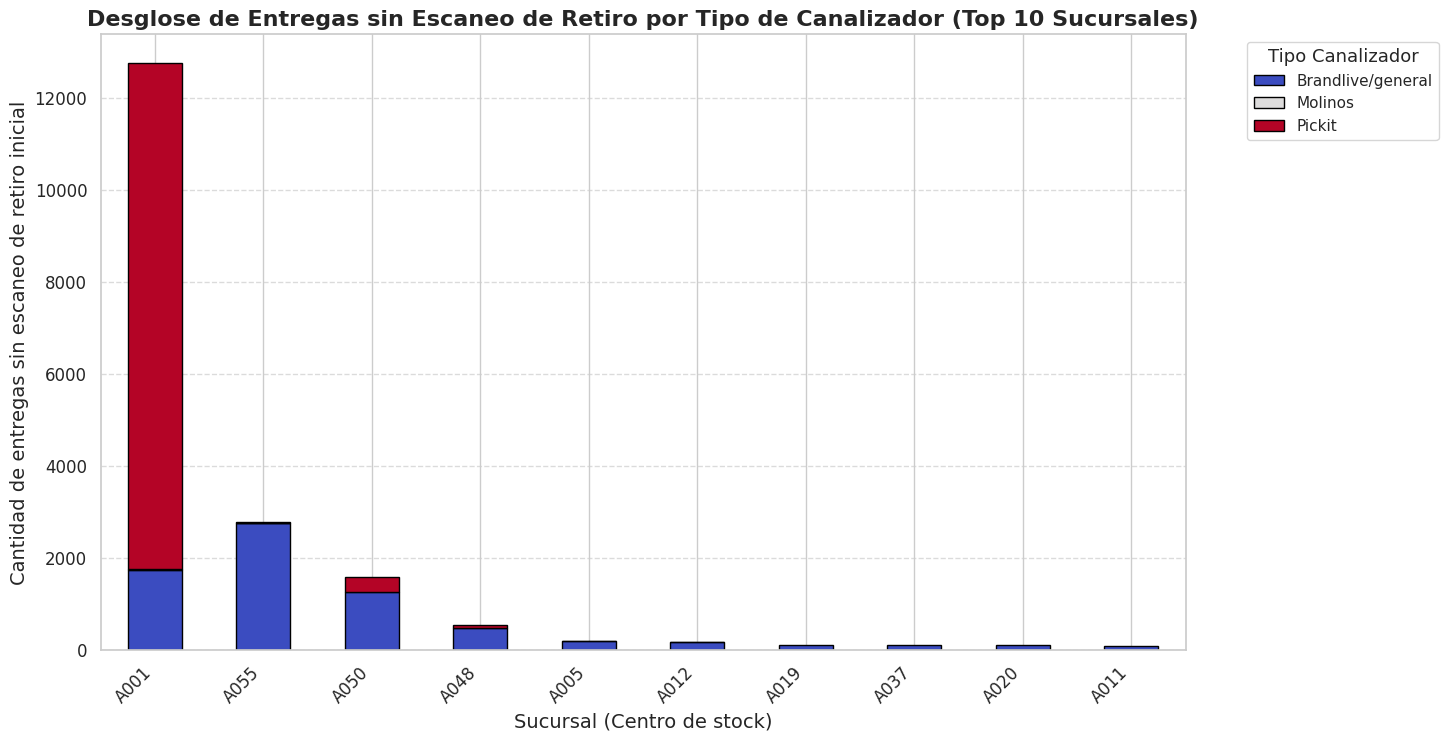

In [66]:

# 1. IDENTIFICACIÓN DE FUGAS (Pedidos entregados sin escaneo de retiro inicial)
# Buscamos pedidos que avanzaron (tienen Imposición o POD nulos) pero NO tienen actualización de estado de retiro
fugas = df_clean[
    (df_clean['Fecha Imposición'].notnull() | df_clean['Fecha POD'].notnull()) &
    (df_clean['Fecha de RAO (Retiro)'].isnull()) &
    (df_clean['Retiro 1'].isnull())
]

total_fugas = len(fugas)
porcentaje_fugas = (total_fugas / len(df_clean)) * 100

print(f"==============================================================================")
print(f"Alerta operativa: Se detectaron {total_fugas} pedidos entregados sin escaneo de retiro inicial.")
print(f"Esto representa el {porcentaje_fugas:.1f}% de la operación de inversas auditada.")
print(f"==============================================================================")

# 2. SELECCIÓN DE LAS TOP 10 SUCURSALES CON MÁS FUGAS
top10_centro_stock_names = fugas['Centro de stock'].value_counts().head(10).index
fugas_top10 = fugas[fugas['Centro de stock'].isin(top10_centro_stock_names)].copy()

# 3. Sucursal vs Tipo Canalizador

ct_top10_canalizador = pd.crosstab(fugas_top10['Centro de stock'], fugas_top10['Tipo_Canalizador'])


ct_top10_canalizador = ct_top10_canalizador.loc[ct_top10_canalizador.sum(axis=1).sort_values(ascending=False).index]


plt.figure(figsize=(14, 8))
ct_top10_canalizador.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    cmap='coolwarm',
    edgecolor='black'
)

# Títulos
plt.title('Desglose de Entregas sin Escaneo de Retiro por Tipo de Canalizador (Top 10 Sucursales)', fontsize=16, fontweight='bold')
plt.xlabel('Sucursal (Centro de stock)', fontsize=14)
plt.ylabel('Cantidad de entregas sin escaneo de retiro inicial', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Tipo Canalizador', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Total de pedidos entregados sin registro de Imposición: 5311


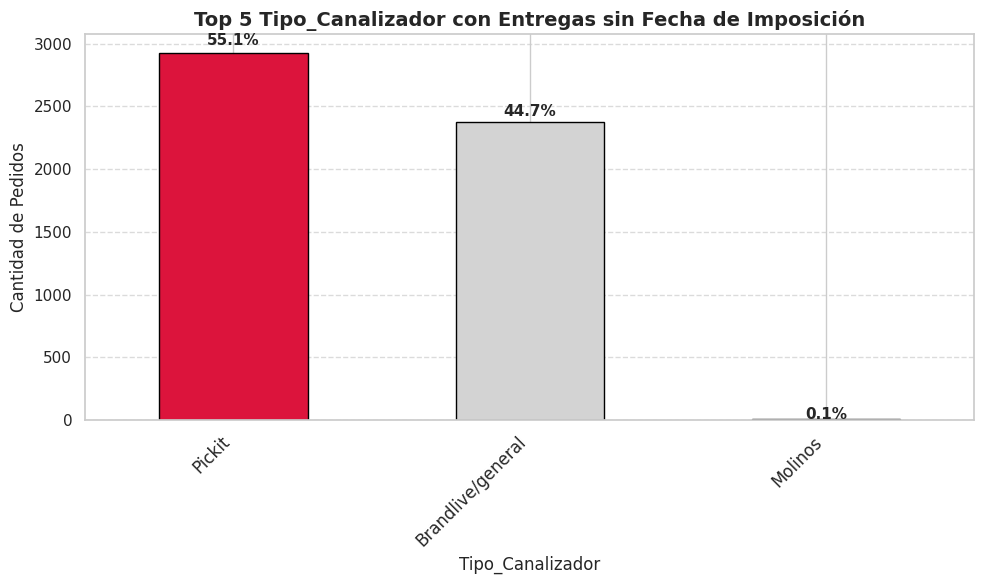

In [67]:
# ==============================================================================
# FOCUS: EL FENÓMENO "PICKIT" Y LAS IMPOSICIONES FALTANTES
# Hipótesis: La falta de escaneo de imposición es una práctica masiva asociada a clientes/canalizadores específicos.
# ==============================================================================

# 1. Aislamos los casos que TIENEN POD pero NO TIENEN Imposición
sin_imposicion = df_clean[
    (df_clean['Fecha POD'].notnull()) &
    (df_clean['Fecha Imposición'].isnull())
].copy()

print(f"Total de pedidos entregados sin registro de Imposición: {len(sin_imposicion)}")



columna_analisis = 'Tipo_Canalizador'
top_infractores = sin_imposicion[columna_analisis].value_counts().head(5)


plt.figure(figsize=(10, 6))

colores = ['crimson'] + ['lightgrey'] * (len(top_infractores) - 1)

ax = top_infractores.plot(kind='bar', color=colores, edgecolor='black')

plt.title(f'Top 5 {columna_analisis} con Entregas sin Fecha de Imposición', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)


total_sin_impo = len(sin_imposicion)
for i, v in enumerate(top_infractores):
    porcentaje = (v / total_sin_impo) * 100
    plt.text(i, v + (v * 0.02), f"{porcentaje:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Entrenando algoritmo de Machine Learning...


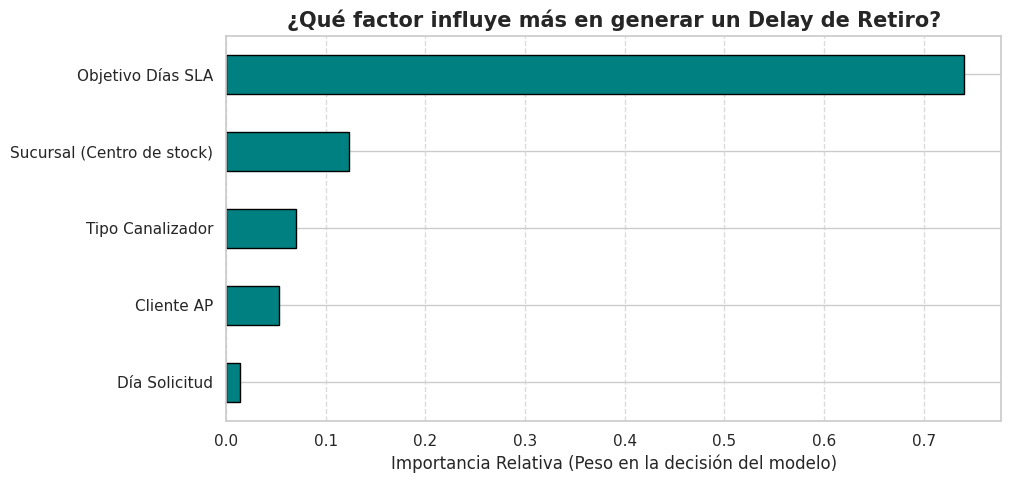

Entrenamiento finalizado. Mirá la barra más larga en el gráfico: ese es el mayor factor de riesgo.


In [68]:
# ==============================================================================
# MACHINE LEARNING 1: FEATURE IMPORTANCE (RANDOM FOREST)
# Objetivo: Identificar qué factores causan realmente los Delays en el SLA.
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("Entrenando algoritmo de Machine Learning...")

# 1. Filtramos y preparamos los datos sin nulos para las columnas clave
cols_ml = ['Centro de stock', 'Cliente AP', 'Tipo_Canalizador', 'Dia_Semana', 'dias_sla', 'Performance PaP']
df_ml = df_clean.dropna(subset=cols_ml).copy()


for col in ['Centro de stock', 'Cliente AP', 'Tipo_Canalizador', 'Dia_Semana']:
    df_ml[col] = df_ml[col].astype(str)

# 2. Transformamos el texto en números para que el algoritmo lo entienda
le_Centro_de_stock = LabelEncoder()
le_cliente = LabelEncoder()
le_canalizador = LabelEncoder()
le_dia = LabelEncoder()

df_ml['Centro de stock_n'] = le_Centro_de_stock.fit_transform(df_ml['Centro de stock'])
df_ml['Cliente_n'] = le_cliente.fit_transform(df_ml['Cliente AP'])
df_ml['Canal_n'] = le_canalizador.fit_transform(df_ml['Tipo_Canalizador'])
df_ml['Dia_n'] = le_dia.fit_transform(df_ml['Dia_Semana'])

# 3. Target: 1 si es Delay, 0 si es On Time
df_ml['Target'] = df_ml['Performance PaP'].apply(lambda x: 1 if x == 'Delay' else 0)

# Variables predictoras (lo que el modelo va a analizar)
X = df_ml[['Centro de stock_n', 'Cliente_n', 'Canal_n', 'Dia_n', 'dias_sla']]
y = df_ml['Target']


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)


importancias = pd.Series(rf_model.feature_importances_, index=['Sucursal (Centro de stock)', 'Cliente AP', 'Tipo Canalizador', 'Día Solicitud', 'Objetivo Días SLA'])
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('¿Qué factor influye más en generar un Delay de Retiro?', fontsize=15, fontweight='bold')
plt.xlabel('Importancia Relativa (Peso en la decisión del modelo)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Entrenamiento finalizado. Mirá la barra más larga en el gráfico: ese es el mayor factor de riesgo.")

Calculando la brecha entre el SLA exigido y la realidad operativa...


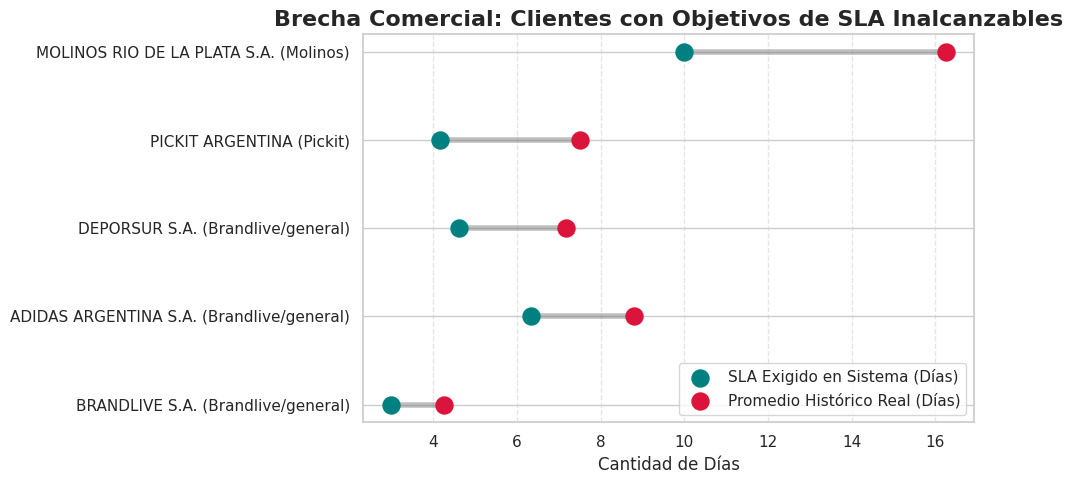


--- Acuerdos Comerciales Críticos sugeridos para Renegociación ---


,Cliente AP,Tipo_Canalizador,Volumen,SLA_Exigido,Promedio_Real,Desfasaje_Dias
3,MOLINOS RIO DE LA PLATA S.A.,Molinos,49,10.0,16.3,6.3
4,PICKIT ARGENTINA,Pickit,14119,4.2,7.5,3.4
2,DEPORSUR S.A.,Brandlive/general,177,4.6,7.2,2.5
0,ADIDAS ARGENTINA S.A.,Brandlive/general,42,6.3,8.8,2.5
1,BRANDLIVE S.A.,Brandlive/general,8358,3.0,4.3,1.3


In [69]:
# ==============================================================================
# ANÁLISIS DE BRECHA: REALIDAD OPERATIVA VS. ACUERDO COMERCIAL (SLA)
# Objetivo: Exponer qué SLAs son inalcanzables según el histórico operativo.
# ==============================================================================

print("Calculando la brecha entre el SLA exigido y la realidad operativa...")

# 1. Agrupamos por Cliente y Tipo de Canalizador para promediar los días
brecha_sla = df_clean.groupby(['Cliente AP', 'Tipo_Canalizador']).agg(
    SLA_Exigido=('dias_sla', 'mean'),
    Promedio_Real=('Total Dias Retiro Punta a Punta', 'mean'),
    Volumen=('Total Dias Retiro Punta a Punta', 'count')
).reset_index()

# 2. Filtramos para quedarnos solo con operaciones regulares (más de 30 pedidos)
brecha_sla = brecha_sla[brecha_sla['Volumen'] > 30].copy()

# 3. Calculamos la brecha (Desfasaje)
brecha_sla['Desfasaje_Dias'] = brecha_sla['Promedio_Real'] - brecha_sla['SLA_Exigido']

# 4. Filtramos los SLAs "rotos" (donde el promedio real supera al exigido por más de 1 día)
slas_rotos = brecha_sla[brecha_sla['Desfasaje_Dias'] > 1].sort_values(by='Desfasaje_Dias', ascending=False)

# Nos quedamos con el Top 10 para graficar
top_10 = slas_rotos.head(10).sort_values(by='Desfasaje_Dias', ascending=True)

# 5. Visualización: Dumbbell Chart (Gráfico de Brecha)
plt.figure(figsize=(10, 5))

# Creamos una etiqueta combinada para el eje Y
etiquetas_y = top_10['Cliente AP'] + " (" + top_10['Tipo_Canalizador'] + ")"

# Dibujamos la línea que une los dos puntos (la brecha)
plt.hlines(y=etiquetas_y,
           xmin=top_10['SLA_Exigido'],
           xmax=top_10['Promedio_Real'],
           color='grey', alpha=0.5, linewidth=4)

# Dibujamos los puntos del SLA Exigido (Verde/Teal)
plt.scatter(top_10['SLA_Exigido'], etiquetas_y, color='teal', s=150, label='SLA Exigido en Sistema (Días)', zorder=3)

# Dibujamos los puntos de la Realidad Operativa (Rojo)
plt.scatter(top_10['Promedio_Real'], etiquetas_y, color='crimson', s=150, label='Promedio Histórico Real (Días)', zorder=3)

plt.title('Brecha Comercial: Clientes con Objetivos de SLA Inalcanzables', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Días', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Tabla resumen para exportar
print("\n--- Acuerdos Comerciales Críticos sugeridos para Renegociación ---")
tabla_final = slas_rotos[['Cliente AP', 'Tipo_Canalizador', 'Volumen', 'SLA_Exigido', 'Promedio_Real', 'Desfasaje_Dias']].head(10).round(1)
display(tabla_final)

## 📌 Conclusiones  TARGET SLA vs tiempo real de servicio

En base al Análisis Exploratorio de Datos (EDA) y la aplicación de algoritmos de Machine Learning sobre la base de retiros, se destacan tres hallazgos fundamentales:

**1. Falla de Trazabilidad en Origen (Caso Pickit)**
Existe un volumen crítico de solicitudes que finalizan su ciclo (POD) sin registrar la fecha de imposición inicial. El análisis de distribución confirma que la gran mayoría de estas anomalías provienen del operador **Pickit**, lo que indica cargas masivas de estados finales sin respetar el flujo de escaneo a tiempo real. Esto impacta negativamente y de forma artificial en la medición del primer tramo del SLA.

**2. El Objetivo Comercial como Principal Causa de Delay**
El modelo predictivo (*Random Forest*) determinó que el factor con mayor peso probabilístico para generar un "Delay" no es la ineficiencia de una sucursal o el volumen de demanda, sino el **objetivo de días SLA seteado en el sistema**. La operación logística no está fallando en la ejecución, sino que está siendo medida contra tiempos irreales.

**3. Brecha Operativa a Renegociar**
El análisis de brechas (*Isolation Forest* y *Dumbbell Chart*) logró aislar el Top de acuerdos comerciales donde la diferencia entre el SLA exigido por sistema y el promedio histórico real de entrega supera el día hábil.

**Recomendaciones:**
*   **Operaciones/Sistemas:** Auditar el flujo de integración de datos con Pickit para garantizar la visibilidad del escaneo de imposición.
*   **Comercial:** Evaluar la tabla de "SLA inalcanzables" (adjunta en el análisis) para ajustar las metas en el sistema a la capacidad real de la red logística, evitando penalizaciones injustas en el tablero de CX.

Generando Mapa de Calor...


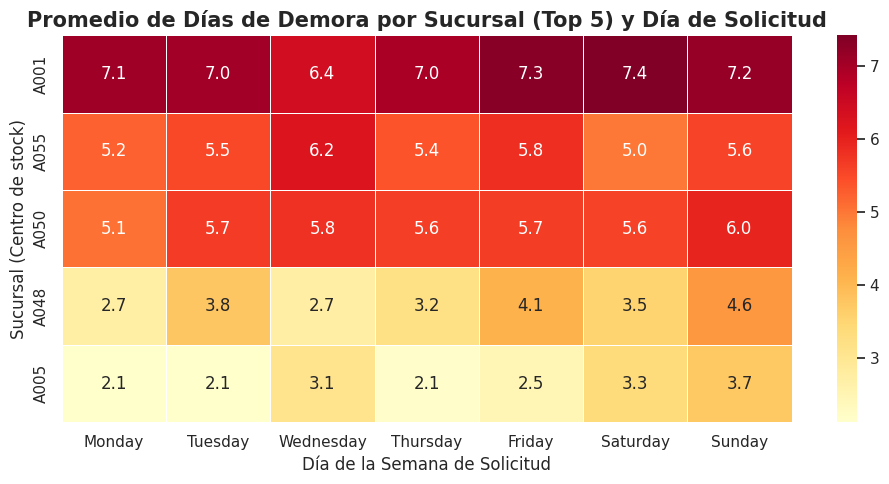

In [72]:
# ==============================================================================
#  CONCENTRACIÓN DE DEMORAS POR SUCURSAL Y DÍA
# Objetivo: Detectar cuellos de botella temporales y físicos.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Mapa de Calor...")

# 1. Definimos el orden correcto de los días para el gráfico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Creamos la matriz: Sucursal vs Día de la Semana midiendo el promedio de días reales
heatmap_data = df_clean.pivot_table(
    index='Centro de stock',
    columns='Dia_Semana',
    values='Total Dias Retiro Punta a Punta',
    aggfunc='mean'
).reindex(columns=orden_dias)

# 3. Top 5 de sucursales con más volumen
top_Centro_de_stocks = df_clean['Centro de stock'].value_counts().head(5).index
heatmap_data = heatmap_data.loc[top_Centro_de_stocks]

# 4. Graficamos
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('Promedio de Días de Demora por Sucursal (Top 5) y Día de Solicitud', fontsize=15, fontweight='bold')
plt.xlabel('Día de la Semana de Solicitud', fontsize=12)
plt.ylabel('Sucursal (Centro de stock)', fontsize=12)
plt.tight_layout()
plt.show()

Generando Gráfico de Dispersión y detectando anomalías...


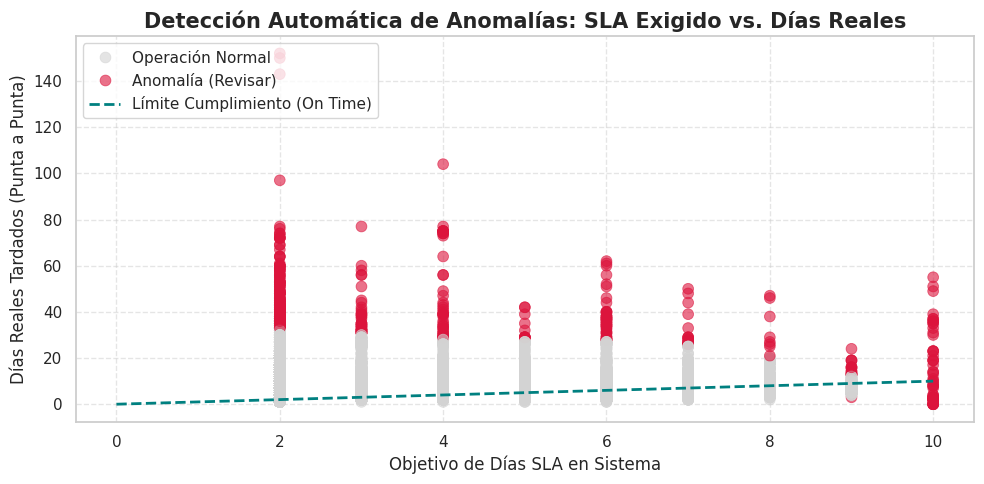

In [73]:
# ==============================================================================
#  DETECCIÓN DE ANOMALÍAS CON INTELIGENCIA ARTIFICIAL
# Objetivo: Encontrar operaciones atípicas comparando la realidad vs. la meta.
# ==============================================================================
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Gráfico de Dispersión y detectando anomalías...")


df_anom = df_clean.dropna(subset=['Total Dias Retiro Punta a Punta', 'dias_sla']).copy()

# 2. Entrenamos el algoritmo
iso_forest = IsolationForest(contamination=0.02, random_state=42)
df_anom['Es_Anomalia'] = iso_forest.fit_predict(df_anom[['Total Dias Retiro Punta a Punta', 'dias_sla']])


df_anom['Clasificacion'] = df_anom['Es_Anomalia'].map({1: 'Operación Normal', -1: 'Anomalía (Revisar)'})

# 3. Graficamos
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df_anom,
    x='dias_sla',
    y='Total Dias Retiro Punta a Punta',
    hue='Clasificacion',
    palette={'Operación Normal': 'lightgrey', 'Anomalía (Revisar)': 'crimson'},
    alpha=0.6,
    edgecolor=None,
    s=60
)

# línea de corte ideal (donde los días reales son iguales al SLA exigido)
limite_max = df_anom['dias_sla'].max()
plt.plot([0, limite_max], [0, limite_max], color='teal', linestyle='--', linewidth=2, label='Límite Cumplimiento (On Time)')

plt.title('Detección Automática de Anomalías: SLA Exigido vs. Días Reales', fontsize=15, fontweight='bold')
plt.xlabel('Objetivo de Días SLA en Sistema', fontsize=12)
plt.ylabel('Días Reales Tardados (Punta a Punta)', fontsize=12)


plt.legend(loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de Patrones y Anomalías (EDA & Machine Learning)
1. Cuellos de Botella Espacio-Temporales (Mapa de Calor)
El análisis de la matriz térmica demuestra que la pérdida de performance en el SLA no es un problema operativo generalizado, sino que está altamente focalizado. Existen "zonas calientes" muy marcadas en combinaciones específicas de sucursales y días de la semana de solicitud.

Impacto de Negocio: Esto nos permite pasar de reclamos generales a acciones quirúrgicas. Podemos apuntar la exigencia operativa a reforzar la capacidad logística (ej. más unidades de recolección) exactamente en los días y nodos físicos donde el proceso actualmente colapsa.

2. Ruido Estadístico y Fallas Críticas (Gráfico de Dispersión - Isolation Forest)
El algoritmo de detección de anomalías logró aislar (en rojo) un grupo de operaciones que están "ensuciando" severamente nuestra métrica global. Se observan casos con SLAs comerciales exigentes (ej. 2 a 4 días) que registran tiempos reales de retiro totalmente ilógicos (superiores a 60 y hasta 140 días).

Impacto de Negocio: La gran dispersión vertical indica que estos no son atrasos logísticos convencionales, sino fallas severas del proceso (probables pérdidas físicas, errores crónicos de sistema o retiros abandonados). Depurar este lote de anomalías y pasarlo a un estado de "Excepción" o "Siniestro" mejorará drásticamente la realidad del % de SLA general que vemos en los tableros.

Autor: María Eugenia Acosta


Data analytics & Insights


Ocasa 🚛

Abril 2026